In [29]:
import os
import sys
from pathlib import Path

# Resolve project root directory to enable imports from src/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import mplhep as mh
mh.style.use("ATLAS")

from src.Parser.NeuralRingerTrainerConfiguration import NeuralRingerTrainerConfiguration
from src.core.Trainers.NeuralRingerTrainer import NeuralRingerTrainer
from src.core.Datasets.SplitManifest import SplitManifest
from src.core.Validation.ResultAggregator import ResultAggregator
from src.core.Validation.HoldoutEvaluator import HoldoutEvaluator, HoldoutEvaluationResult
from src.core.Validation.EfficiencyPlotter import EfficiencyPlotter
from src.core.Validation.ModelValidator import ModelValidator
from src.utils import get_et_eta



print(f"Project root: {PROJECT_ROOT}")
print(f"PyTorch version: {torch.__version__}, CUDA available: {torch.cuda.is_available()}")

Project root: /eos/home-i04/p/pmourafr/egamma_master
PyTorch version: 2.10.0, CUDA available: True


### Load Configuration & Configure Paths

In [2]:
CONFIG_PATH = PROJECT_ROOT / "config/NeuralRinger/ModelV6_HighBatch_newExtraction_20_regions_100RingsNoFilter.yaml"
RESULTS_PATH = PROJECT_ROOT / "results"
DATA_PATH = PROJECT_ROOT / "data/consolidated"
OUTPUT_DIR = PROJECT_ROOT / "Plots/Validation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(CONFIG_PATH, "r") as f:
    config_dict = yaml.safe_load(f)

# Override dataset drive_path with local data directory if available
if DATA_PATH.exists():
    config_dict["dataset"]["parameters"]["drive_path"] = str(DATA_PATH)
    print(f"data path: {config_dict["dataset"]["parameters"]["drive_path"]}")

config = NeuralRingerTrainerConfiguration.model_validate(config_dict)
print(f"Loaded experiment: {config.config_name}")
print(f"Architecture: {config.model.object_name}, Input dimension: {config.model.parameters.get('input_dim')}")

trainer = NeuralRingerTrainer(config)
dataset = trainer.full_dataset
model = trainer.factory.create_model()
device = trainer.device
kfold = trainer.factory.create_cross_validation()
print(f"Target computation device: {device}")
print(f"Discovered dataset region files: {len(dataset)}")

data path: /eos/home-i04/p/pmourafr/egamma_master/data/consolidated
Loaded experiment: ModelV6_HighBatch_newExtraction_20_regions_100Rings
Architecture: ModelV6, Input dimension: 100


Target computation device: cuda
Discovered dataset region files: 25


### Step-by-Step Data Validation

In [11]:
if len(dataset) > 0:
    features, labels, file_path = dataset[6]
    print(f"\nInspecting region file: {file_path}")
    print(f"Feature matrix shape: {features.shape}")
    print(f"Target vector shape:  {labels.shape}")
    print(f"Signal events (class 1):     {(labels == 1).sum()}")
    print(f"Background events (class 0): {(labels == 0).sum()}")
    print(f"Active ring column indices:  {len(dataset.ring_column_indices)}")
    et, eta = get_et_eta(file_path)


Inspecting region file: /eos/home-i04/p/pmourafr/egamma_master/data/consolidated/consolidated.et1.eta1.npz
Feature matrix shape: (144311, 181)
Target vector shape:  (144311,)
Signal events (class 1):     40463
Background events (class 0): 103848
Active ring column indices:  100


In [10]:
samples = np.load(file_path, allow_pickle=True)
data = samples["data"]
source = samples["source"]

ph_eta_index = np.where(dataset.feature_names == "ph_eta")[0][0]
ph_et_index = np.where(dataset.feature_names == "ph_et")[0][0]
trig_L2_calo_eta_index = np.where(dataset.feature_names == "trig_L2_calo_eta")[0][0]
trig_L2_calo_et_index = np.where(dataset.feature_names == "trig_L2_calo_et")[0][0]

print(f"Using file {file_path}")

ph_eta = data[:, ph_eta_index].flatten()
print(f"{ph_eta.min() = :.3f}\t{ph_eta.max() = :.3f}")

ph_et = data[:, ph_et_index].flatten()
print(f"{ph_et.min() = :.3f}\t{ph_et.max() = :.3f}")

trig_L2_calo_eta = data[:, trig_L2_calo_eta_index].flatten()
print(f"{trig_L2_calo_eta.min() = :.3f}\t{trig_L2_calo_eta.max() = :.3f}")

trig_L2_calo_et = data[:, trig_L2_calo_et_index].flatten()
print(f"{trig_L2_calo_et.min() = :.3f}\t{trig_L2_calo_et.max() = :.3f}")

Using file /eos/home-i04/p/pmourafr/egamma_master/data/consolidated/consolidated.et1.eta1.npz
ph_eta.min() = -1.689	ph_eta.max() = 1.763
ph_et.min() = 25000.002	ph_et.max() = 447292.000
trig_L2_calo_eta.min() = -1.370	trig_L2_calo_eta.max() = 1.370
trig_L2_calo_et.min() = 20000.785	trig_L2_calo_et.max() = 29999.980


In [60]:
n_results = RESULTS_PATH / "config_nameModelV6_HighBatch_newExtraction_20_regions_100Rings_id20260929035222"
manifest_path = os.path.join(n_results, "split_manifest.json")
manifest = SplitManifest(manifest_path)
region_key = f"et_{int(et)}_eta_{int(eta)}"
print(f"Using {region_key}")

test_indices, train_cross_validation = manifest.get_or_create_region_splits(
    region_key, features, labels, kfold)

# holdout_features_full = features[test_indices]
# holdout_labels = labels[test_indices]

all_indices = np.arange(len(labels))
train_val_indices = ~np.isin(all_indices, test_indices)
test_indices = np.isin(all_indices, test_indices)

print(f"{features[train_val_indices].shape = }")
print(f"{features[test_indices].shape = }")


Using et_1_eta_1
features[train_val_indices].shape = (129879, 181)
features[test_indices].shape = (14432, 181)


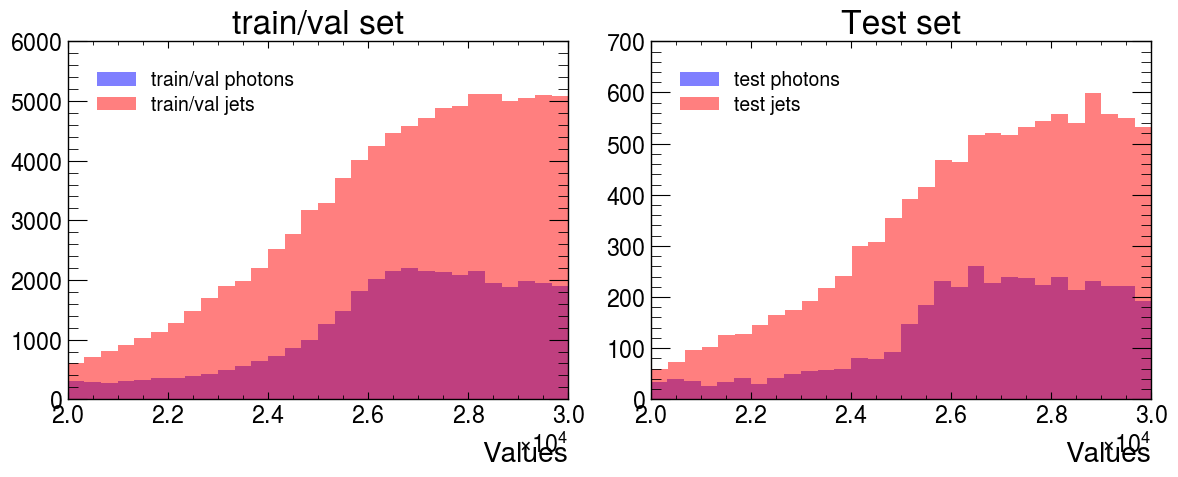

In [ ]:
BINS = 30

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(features[(train_val_indices) & (labels == 1), trig_L2_calo_et_index], bins=BINS,
         label="train/val photons", density=False, alpha=0.5, color="blue")
ax1.hist(features[(train_val_indices) & (labels == 0), trig_L2_calo_et_index], bins=BINS,
         label="train/val jets", density=False, alpha=0.5, color="red")
ax1.set_title('train/val set')
ax1.set_xlabel('Values')
ax1.legend()

ax2.hist(features[(test_indices) & (labels == 1),trig_L2_calo_et_index], bins=BINS,
    label="test photons", density=False, alpha=0.5, color="blue")
ax2.hist(features[(test_indices) & (labels == 0),trig_L2_calo_et_index], bins=BINS,
    label="test jets", density=False, alpha=0.5, color="red")
ax2.set_title('Test set')
ax2.set_xlabel('Values')
ax2.legend()

plt.tight_layout()
plt.show()
